In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="6" color="red">ch10. 파일 N차원배열다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 독립변수 : 원인(내가 바꾸는 것) / 종속변수 : 원인으로 인해 변하는 것(결과)
- 1차원: 단순한 리스트 [' ']
- 2차원: 리스트안에 리스트가 있는 형태 (행과 열) [ [' '] ]
- 3차원: 리스트 안에 리스트 안에 리스트 (층, 행, 열) [[ [' '] ]]
- 4차원: 리스트 안에 리스트 안에 리스트 안에 리스트 (데이터 묶음, 층, 행, 열) [[[ [' '] ]]]
- [numpy](https://numpy.org) - LMM 관련 정보는 Gpt가 제일 거짓말을 많이하므로, 신뢰할만한 출처 사이트
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.htm1) - 새로운 함수에 대한 정보
# 1절. 넘파이 패키지

In [2]:
import numpy as np
np.__version__ # tensorflow==2.10과 맞는 numpy 버전

'1.23.5'

In [5]:
# np.arange(from,stop,by) : from부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) #  a 몇차원인지 확인하는 명령어  ->  15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성
- 배열 생성 -> 변수 = arange(생성할 숫자 갯수).reshape(행, 열)
- 변수.size = 원소의 개수
- 변수.dtype = dtype('int비트') -> 1Byte = 8bit
- 변수.itemsize = 요소 하나의 메모리(byte)사이즈
- 변수.dtype = np.int64 -> int 수정전 -> int64로 변경
- itemsize의 계산 = int64 ÷ 8 = 8bit = itemsize는 8

In [76]:
from numpy import arange 
a = arange(15, 
                       # dtype=np.int8
                        ).reshape(3, 5) # -> (3행 5열로 변환)해라
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [465]:
# 복습
from numpy import arange # import : 다른 파일에 있는 기능을 현재 파일에서 사용할 수 있도록 가져오는 키워드.
ex_a = arange(24).reshape(3, 8)
ex_a

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20, 21, 22, 23]])

In [469]:
type(a) # a변수의 타입

numpy.ndarray

In [470]:
ex_a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [471]:
ex_a.dtype.name

'int32'

In [472]:
ex_a.itemsize # 한 요소(item)의 byte size

4

In [473]:
ex_a.ndim # 축수 (차원수)

2

In [474]:
ex_a.shape # 배열 구조(2차원 3행5열)

(3, 8)

In [83]:
a.shape = (3,5) # 3행 5열 조정전
print('shape 조정전 a:\n', a)
a.shape = (5,3) # 5행 3열로 조정후
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [84]:
a.reshape(3, 5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [85]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [86]:
# 배열 요소의 타입변경(부적절한 예시)
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [87]:
# 요소갯수
a.size

12

In [88]:
# 32bit씩 읽겠다
a.dtype

dtype('int32')

In [89]:
a.itemsize

4

In [90]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [91]:
# 요소의 byte수
a.itemsize

8

In [92]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [93]:
# 요소 갯수
a.size

6

In [94]:
# 배열 요소의 타입변경(올바른 예시)
a = arange(15).reshape(5, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [134]:
# a의 타입을 변경해라 -> 64비트로
# a.astype(np.int64) # 출력할 경우 -> a가 바뀌지 않음. / 출력X -> a바뀜
a = a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [135]:
a.dtype

dtype('int64')

In [136]:
a.itemsize

8

In [137]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [138]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [139]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체저장, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [140]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [141]:
%%time
import time
start = time.time() # 1970.1.1부터 지금까지의 초수
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

실행 시간 : 0.0009918212890625
CPU times: total: 46.9 ms
Wall time: 992 µs


In [142]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 0 ns
Wall time: 1e+03 µs


In [143]:
# a ==(파일저장)==> 피클파일(269B) ==(Load)==> Loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [144]:
%%time
np.save('data/ch11.npy', a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 962 µs


In [145]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 7.27 ms


In [146]:
# a ==(저장)==> npy(248B) == (Load) ==> Loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.....
- 랜덤값을 갖는 배열 생성함수 ~......
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(리스트나 튜플 object, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64, ...

In [149]:
a = np.array([2, 14, 6]
                     # dtype=np.int16
                  ) # 정수의 기본 타입은 int32/실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [150]:
a[0], a[1], a[2]

(2, 14, 6)

In [151]:
for item in a:
    print(item, end='\t')

2	14	6	

In [158]:
b = np.array([[1.5, 2.3],   # 동일자료형의 집합으로 배열 생성 : 정수>실수>문자
                      [4, 5]])        # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [204]:
b.dtype

dtype('float64')

In [205]:
l = [[1.5, 2.3],[4,5]]
l[0][1]

2.3

In [206]:
b[0,1] # 2차원 [axis0=행, axis1=열] cf. 1차원[axis0=열]

2.3

In [207]:
a = np.array([[1.5, 2.3],
                     [4,5]],
             # dtype="float32"
             dtype=np.float32
                     ).reshape(2,2) # )뒤에.reshape(행, 열) 가능
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [208]:
a.dtype

dtype('float32')

In [214]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [215]:
# a의 dtype(요소의 타입) 변경
# 부적절한 예시) a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [216]:
l = [[1.5, 2.3],
    [4,5]]
for row in l: # for문의 row는 행을 하나씩 가져온다.
    for item in row: # 해당 for문은 row 안의 요소(item)를 하나씩 가져온다.
        print(item, end=' ')
    print()

1.5 2.3 
4 5 


In [217]:
for i, row in enumerate(l):   # enumaerate()는 반복문에서 인덱스(번호)와 값을 동시에 가져오는 함수. -> 1 사과 / 2 바나나
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end='\t')
        print()

0행0열 : 1.5	
0행1열 : 2.3	
1행0열 : 4	
1행1열 : 5	


In [218]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소수점 이하 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [220]:
print(b[0,0]) # 인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

1.5


In [225]:
# 슬라이싱 from:stop:by, 0행:끝행, 1열부터 10열전까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)
b[0:, 1:10]

array([[2.3],
       [5. ]])

In [226]:
b[0:1, 1:3] # 0행, 1열부터 3열 전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([[2.3]])

In [265]:
b = np.array([[1,2,3],
                      [6,7,8]])
b[:, -1:], b[:, -1]
# 모든 행의 마지막 열만 추출

(array([[3],
        [8]]),
 array([3, 8]))

In [271]:
# 모든 행의 마지막 열을 제외한 부분 추출
b = np.array([[1,2,3],
                      [6,7,8]])
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [275]:
# 스칼라 변수
a = 10 # 원본
b = a  # 복제본
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=1946391675408, b주소=1946391675408
a=10, b=-1, a주소=1946391675408, b주소=1946391675056


In [285]:
# numpy 배열
c = np.array([[-1, 2], [3,4]], dtype=np.uint16) # uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능
d = np.array(c, copy=False) # d = c 동일 # 할당
# int8 = 부호가 들어가기때문에 최대 경우의 수가 256(0~255까지)이므로 -와 + 둘다 처리하게되면 -128 ~ +127만 표현가능
# uint8는 부호가 없기때문에 8비트 전부를 숫자로 표현 가능하므로, 0 ~ 255 표현 가능
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[65535     2]
 [    3     4]]
d=
[[65535     2]
 [    3     4]]
두 변수의 주소 : 1946519463248 1946519463248
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1946519463248 1946519463248


In [286]:
c = np.array([[-1, 2], [3,4]], dtype=np.uint16) # uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능
d = np.array(c, copy=True) # d = c.copy()와 동일 # 깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[65535     2]
 [    3     4]]
d=
[[65535     2]
 [    3     4]]
두 변수의 주소 : 1946519463824 1946519464400
c=
[[65535     2]
 [    3     4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1946519464400 1946519464400


In [288]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[-1, 2], [3,4]],    dtype=np.int16) # -> 원본 uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능 
d = np.array(c, copy=False,  dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[-1  2]
 [ 3  4]]
d=
[[-1  2]
 [ 3  4]]
두 변수의 주소 : 1946533547824 1946533548304
c=
[[-1  2]
 [ 3  4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1946533548304 1946533548304


# 4절. 복사와 뷰
## 4.1 할당

In [289]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b데이터 :', a, b)

a와 b주소 : 1946391675408 1946391675408
수정 후 a와 b주소 : 1946391675408 1946391678256
수정 후 a와 b데이터 : 10 99


In [295]:
# 배열
a = np.arange(0, 13, 2)
print(a)
ab = np.arange(12)
print(ab)

[ 0  2  4  6  8 10 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [296]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((7,), numpy.ndarray, 1, 1946533545328)

In [449]:
a = np.array([[99,88,77,88],
                      [99,88,77,88],
              [99,88,77,88]])
b = a
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1946649688176)

In [450]:
a.shape, type(a), b.ndim, id(a)

((3, 4), numpy.ndarray, 2, 1946649688176)

In [451]:
a is b

True

In [452]:
a == b # 요소별 비교

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [453]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [454]:
b.shape = (3, 4)

In [455]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1946649688176)

In [456]:
a.shape

(3, 4)

In [457]:
a

array([[99, 88, 77, 88],
       [99, 88, 77, 88],
       [99, 88, 77, 88]])

## 4.2 뷰(view) : 얕은 복사

In [458]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [313]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [314]:
id(a), id(c)

(1946526708528, 1946519466224)

In [318]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [319]:
np.all(a==c)

True

In [320]:
a is c

False

In [322]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [323]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [324]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [351]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경 외에는 원본도 변경)
a = np.array([[99, 88, 77, 85],
                      [88, 71, 77, 77],
                      [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [360]:
# 얕은 복사 (view생성) X = a[:, :-1]
X = a[:, :-1].copy() # 깊은 복사
# X = np.array(a[:, :-1], copy=True) # 깊은 복사

In [362]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup [,dtype] ) : 요소들이 다 0.0
- np.ones( tup [,dtype] ) : 요소들이 다 1.0
- np.full( tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.emtpy(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음

In [367]:
np.zeros( (3, 5) ) # 3행동5열짜리 2차원 float64 배열 (요소들은 다 0)
np.zeros( (5,) )

array([0., 0., 0., 0., 0.])

In [380]:
x = np.zeros ( (2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print()

[[False False False False False]
 [False False False False False]]
bool



In [381]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


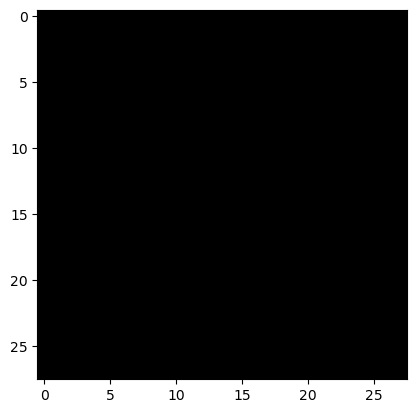

In [459]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검정색
# plt.figure(figsize=(1, 1))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [460]:
import numpy as np
np.empty( (3,2) )

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖은 tup 사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값

- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포 (평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n개)

- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개 발생 == random.randint(from, to-1)

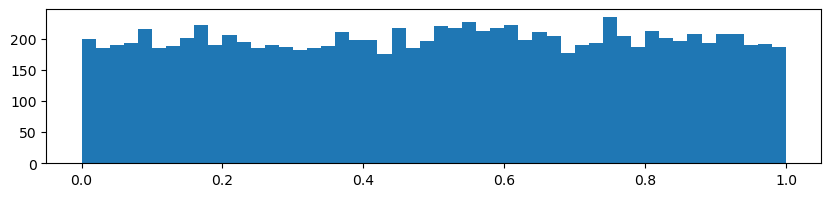

In [461]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
# x = np.random.random(10)
# x = np.random.uniform(1, 10, 1000)
x = np.random.rand(10000)
plt.hist(x, bins=50)
plt.show()

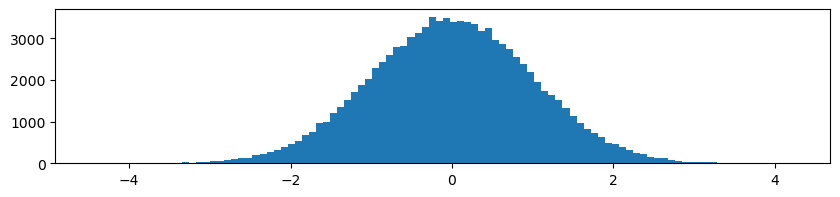

In [462]:
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(50, 10, 1000000) # 표준정규분포
x = np.random.randn(100000) # 표준정규분포
plt.hist(x, bins=100)

plt.show()